# Acoustic plots

This tutorial was prepared by Alexandre Olender olender@usp.br

This tutorial focuses on solving using Spyro's ploting methods.

In [1]:
# Code in this cell enables plotting in the notebook
%matplotlib inline

import spyro
import numpy as np

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified

Authorization required, but no authorization protocol specified



Let us begin by setting up a spiro forward problem

In [2]:
dictionary = {}
dictionary["camembert_options"] = {
    "radius": 0.2,
    "circle_center": (-1.0, 1.0),
    "outside_velocity": 2.5,
    "inside_circle_velocity": 3.0,
}
dictionary["mesh"] = {
    "length_z": 2.0,  # depth in km - always positive
    "length_x": 2.0,  # width in km - always positive
    "h": 0.1,  # mesh size in km
    "length_y": 0.0,  # thickness in km - always positive
    "mesh_type": "firedrake_mesh",
}
dictionary["acquisition"] = {
    "source_type": "ricker",
    "source_locations": [(-0.55, 1.0)],
    "frequency": 5.0,
    "delay": 0.2,
    "delay_type": "time",
    "receiver_locations": spyro.create_transect((-1.45, 0.7), (-1.45, 1.3), 200),
    "use_vertex_only_mesh": True,
}
dictionary["time_axis"] = {
    "initial_time": 0.0,  # Initial time for event
    "final_time": 0.8,  # Final time for event
    "dt": 1e-3,  # timestep size
    "amplitude": 1,  # the Ricker wave has an amplitude of 1.
    "output_frequency": 100,  # how frequently to output solution to pvds
    "gradient_sampling_frequency": 1,  # how frequently to save solution to RAM
}
dictionary["absorving_boundary_conditions"] = {
    "status": True,  # True or false
}
wave = spyro.examples.Camembert_acoustic(dictionary=dictionary)
wave.store_forward_time_steps = True  # For visualization purposes this will save the propagation solution at the gradient sampling frequency.
wave.forward_solve()


Parallelism type: automatic
No Absorbing Boundary Conditions (ABCs) applied.
Pad length will be determined with HABC criterion
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Mesh incomplete: 'firedrake_mesh' requires either 'edge_length' or 'cells_per_wavelength'.
Skipping mesh generation, since we don't have all the parameters
Creating firedrake_mesh type mesh.
Mesh Created with 441 Nodes and 800 Area Elements


/workspaces/elastic/spyro/solvers/wave.py:166: UserWarning: No mesh file, Firedrake mesh will be automatically generated.
  warnings.warn(



Solving Forward Problem
Saving Pressure in: results/camembert_forward_outputsn[0].pvd
Simulation time is:        0.0 seconds
Simulation time is:        0.1 seconds
Simulation time is:        0.2 seconds
Simulation time is:        0.3 seconds
Simulation time is:        0.4 seconds
Simulation time is:        0.5 seconds
Simulation time is:        0.6 seconds
Simulation time is:        0.7 seconds
Simulation time is:        0.8 seconds


We can have a look at our velocity model that's actually been used. If we were to just save it in a VTKFile and open with paraview, we would need to use a tesselation filter because of the high order elements to ore accuratelly generate images. Spiro has a plot function where you can choose you resolution.

/usr/local/lib/python3.12/dist-packages/segyio/utils.py:18: RuntimeWarning: Implicit conversion to contiguous array
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/segyio/utils.py:23: RuntimeWarning: Implicit conversion from float64 to float32 (narrowing)
  warnings.warn(msg.format(x.dtype, dtype), RuntimeWarning)


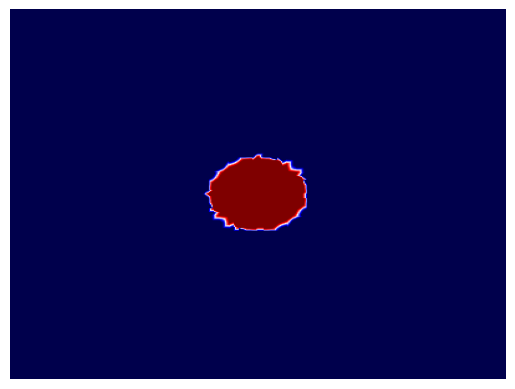

In [3]:
resolution = 0.005
spyro.io.export_scalar_field(wave.c, resolution, "camembert.png", comm=wave.comm, show=True)

If we were to just use a regular plot we would get an innacurate (with only first order data) image like the one shown below:

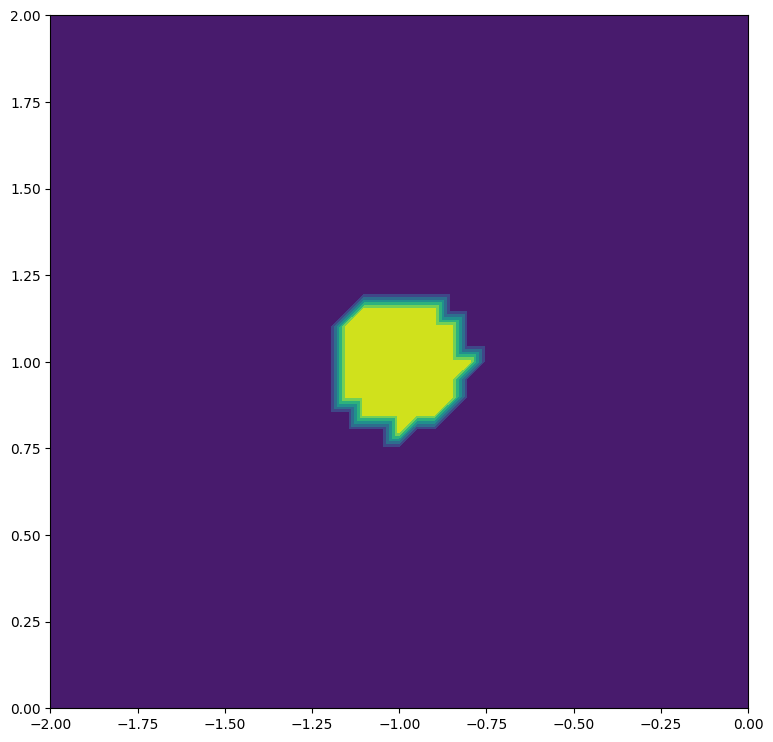

In [4]:
import matplotlib.pyplot as plt
from firedrake import tricontourf
fig = plt.figure(figsize=(9, 9))
axes = fig.add_subplot(111)
fig.set_figwidth = 9.0
fig.set_figheight = 9.0
tricontourf(wave.c, axes=axes)

We can also look at the pressure value accross all our domain at any saved timestep. Let us check our last one

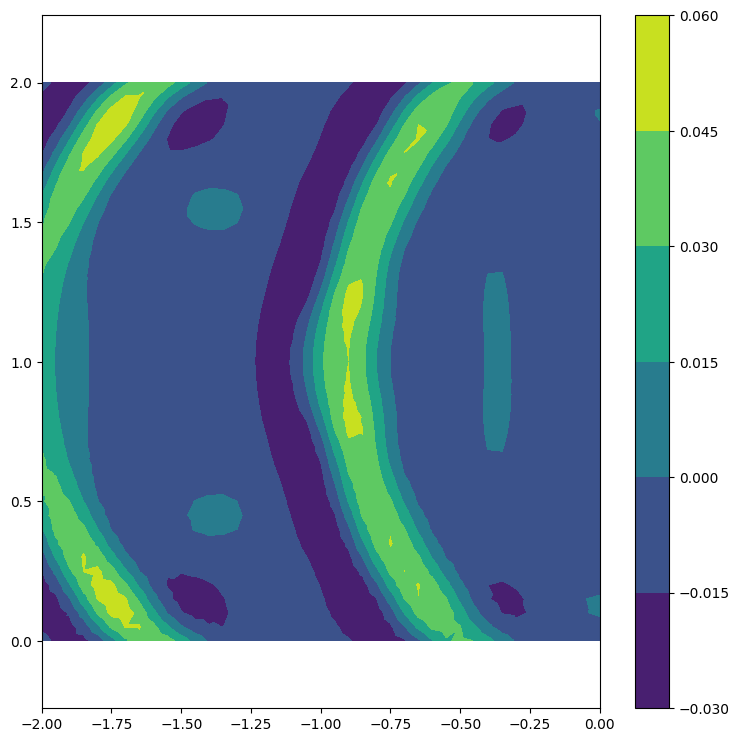

In [5]:
last_pressure = wave.u_n
spyro.plots.plot_function(last_pressure)

This result looks a bit weird. Could it be that most of the wave has allready left our domain and we are looking only at the minor non basorbed reflections? To check, we can also have a look at our receiver response. For the acoustic wave the receivers measure pressure values. Every measurement for the NT timestep number and NR receiver number is stored in a np.ndarray of NTxNR size. We can plot the 100th receiver response like this:

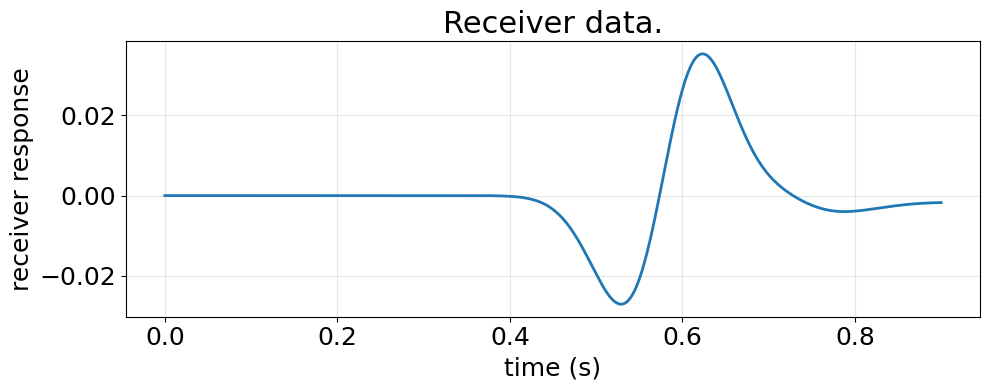

In [6]:
spyro.plots.plot_receiver_response(wave.forward_solution_receivers[:, 100], final_time=0.9, show=True)

Let us also look at our shot record, where the direct wave is very visible

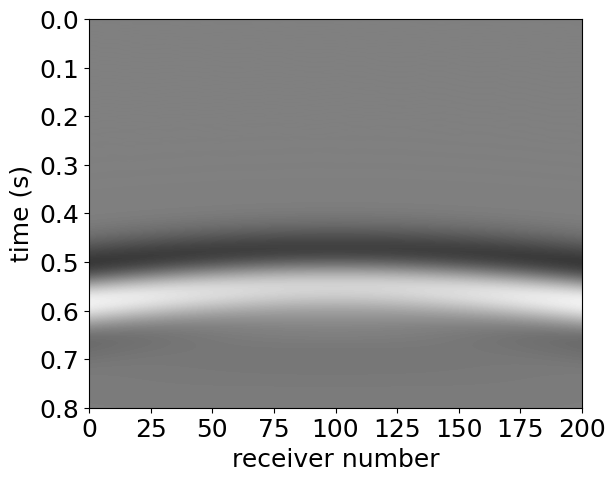

In [7]:
last_pressure_data = last_pressure.dat.data[:]
spyro.plots.plot_shots(wave, contour_lines=100, vmin=-np.max(last_pressure_data), vmax=np.max(last_pressure_data), show=True)

We can notice that the wave front hits the receiver 100 at around 0.5 seconds. Let us check how our wavfield looks at that time.

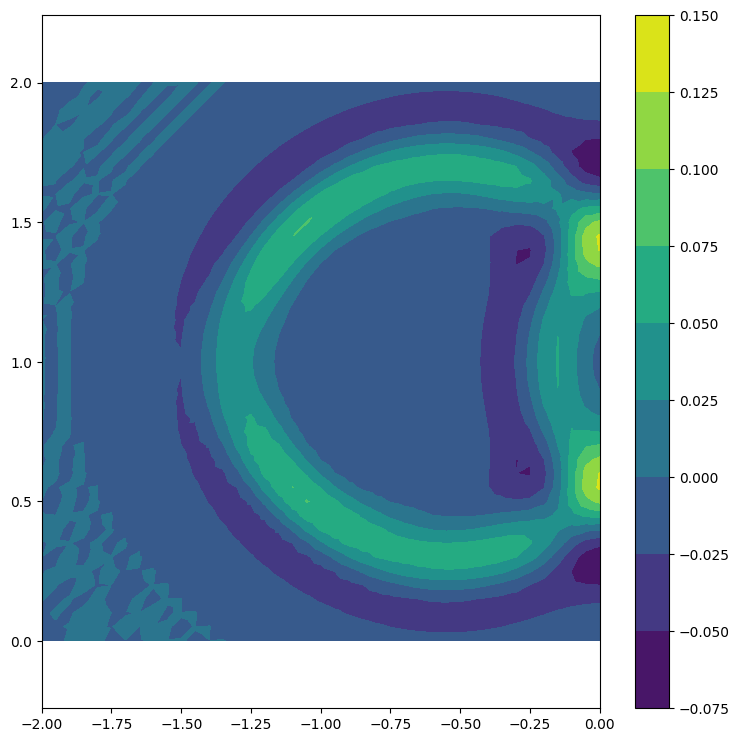

In [16]:
pressure_at_half_a_second = wave.forward_solution[500]
spyro.plots.plot_function(pressure_at_half_a_second)